## Model Generalization on Unseen Datasets

Evaluate how the CNN Model performs on  unseen datasets (e.g., images collected from different clinics or MRI machines) in various metrics.

We will test using our trained weights on the testing folders of:
* `other1_brain_mri_dataset`
* `other2_brain_mri_dataset`


### Prep and Loading
This section handles image processing and loading the two datasets. The processing includes:  
* Resizing all brain MRI scans to a $256 \times 256$ resolution and converting them into PyTorch tensors.
* Transforming images to one channel through Grayscaling
* Organizing images into `Training` and `Testing` sets using `ImageFolder` (mapping subdirectories to class labels).
* Creates data streams (`DataLoaders`) to process images in batches of 32.

In [2]:
import torch
from torchvision import datasets, transforms

# paths to the Testing subfolders of new datasets
other1_path = 'other1_brain_mri_dataset/Testing/'
other2_path = 'other2_brain_mri_dataset/Testing/'

# transform for testing images by converting to Tensors with 256x256 ratio
test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# load datasets
other1_dataset = datasets.ImageFolder(root=other1_path, transform=test_transform)
other2_dataset = datasets.ImageFolder(root=other2_path, transform=test_transform)

# create dataloaders 
other1_loader = torch.utils.data.DataLoader(other1_dataset, batch_size=32, shuffle=False)
other2_loader = torch.utils.data.DataLoader(other2_dataset, batch_size=32, shuffle=False)

class_names = other1_dataset.classes  

print('Data Loaded Successfully...\n')

Data Loaded Successfully...



### Model Architecture

This section defines a custom CNN for classifying 4 distinct categories in the brain MRI dataset. The model includes:

Feature Extraction (convolutional layers each followed by batch normalization to stabilize training):
* Conv1: Accepts an RGB image (3 channels) and extracts 16 features. Max pooling halves the spatial resolution from $256 \times 256 \rightarrow 128 \times 128$.
* Conv2: Expands feature maps from 16 to 32. Max pooling halves the size from $128 \times 128 \rightarrow 64 \times 64$.
* Conv3: Expands feature maps from 32 to 64. Max pooling halves the final size from $64 \times 64 \rightarrow 32 \times 32$.
* Conv4: Expands feature maps from 64 to 128. Max pooling halves the final size from $32 \times 32 \rightarrow 16 \times 16$.  

Classification (fully connected layers):
  * Flatten Layer: Flattens the 3D feature maps into a 1D vector.
  * Linear 1: Maps features down to 512 dense representations with a ReLU activation function.
  * Dropout Layer: Randomly zeroes out neurons during training for regularization.
  * Linear 2: Outputs raw logits for the 4 target classification categories.

In [3]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # cut image size by half

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)  # input size: 256x256
        self.bn1 = nn.BatchNorm2d(num_features=16) # Match out_channels

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1) # input size: 128x128
        self.bn2 = nn.BatchNorm2d(num_features=32)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1) # input size: 64x64
        self.bn3 = nn.BatchNorm2d(num_features=64)

        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1) # input size: 32x32
        self.bn4 = nn.BatchNorm2d(num_features=128)

        self.dropout = nn.Dropout()
        self.full_conn1 = nn.Linear(in_features=128 * 16 * 16, out_features=512)  # input size: 16x16
        self.full_conn2 = nn.Linear(in_features=512, out_features=4)  # output size: 4 classes

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # output size: 128x128
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # output size: 64x64
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # output size: 32x32
        x = self.pool(F.relu(self.bn4(self.conv4(x))))  # output size: 16x16

        x = torch.flatten(x, start_dim=1)  # flatten the tensor for fully connected layer
        x = F.relu(self.full_conn1(x))
        x = self.dropout(x)
        x = self.full_conn2(x)
        return x

model = SimpleCNN()
print(model)

SimpleCNN(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (full_conn1): Linear(in_features=32768, out_features=512, bias=True)
  (full_conn2): Linear(in_features=512, out_features=4, bias=True)
)


### Model and Device Loading
This section loads the evaluation device and saved model weights for evaluation of datasets.

In [4]:
# load device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# load saved model weights
model.load_state_dict(torch.load('brain_mri_cnn_v5.pth', map_location=device))
model = model.to(device)
model.eval()
print('Model successfully built and weights loaded...\n')

Using device: cpu
Model successfully built and weights loaded...



### Define Evaluation Function
This section defines the function that runs the evaluation loop on datasets. For each dataset, it does the following:
* Prints classification report
* Generates and plots the Heat Map of Confusion Matrix

In [10]:
# evaluates metrics for given dataset
def evaluate_dataset(dataloader, dataset_name):
    print(f"\nEvaluating Dataset: {dataset_name}...")
    
    all_true_labels = []
    all_pred_labels = []
    
    # run predictions with gradient calculations disabled
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            
            _, predicted = torch.max(outputs, 1)
            
            # save predictions and actual labels
            all_true_labels.extend(labels.cpu().numpy())
            all_pred_labels.extend(predicted.cpu().numpy())
            
    # print classification report
    print(f"\n================ FINAL PERFORMANCE REPORT: {dataset_name} ================")
    print(classification_report(all_true_labels, all_pred_labels, target_names=class_names, digits=4))
    print("===================================================================\n")
    
    # generate and plot heatmap Confusion Matrix
    cm = confusion_matrix(all_true_labels, all_pred_labels)
    
    plt.figure(figsize=(7, 5.5))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        xticklabels=class_names, 
        yticklabels=class_names
    )
    plt.title(f'Confusion Matrix Heatmap\nDataset: {dataset_name}')
    plt.xlabel('Predicted Diagnostic Category', fontsize=10)
    plt.ylabel('Actual True Clinical Category', fontsize=10)
    plt.tight_layout()
    plt.show()

print('Evaluation Function Loaded Successfully...')

Evaluation Function Loaded Successfully...


### Run Performance Testing
Runs defined evaluation function with unseen datasets:
* `other1_brain_mri_dataset`
* `other2_brain_mri_dataset`


Evaluating Dataset: other1_brain_mri_dataset...

================ FINAL PERFORMANCE REPORT: other1_brain_mri_dataset ================
              precision    recall  f1-score   support

      glioma     0.9321    0.9724    0.9518       254
  meningioma     0.7955    0.9281    0.8567       306
     notumor     0.9524    0.4286    0.5911       140
   pituitary     0.9492    0.9967    0.9724       300

    accuracy                         0.8900      1000
   macro avg     0.9073    0.8314    0.8430      1000
weighted avg     0.8983    0.8900    0.8784      1000




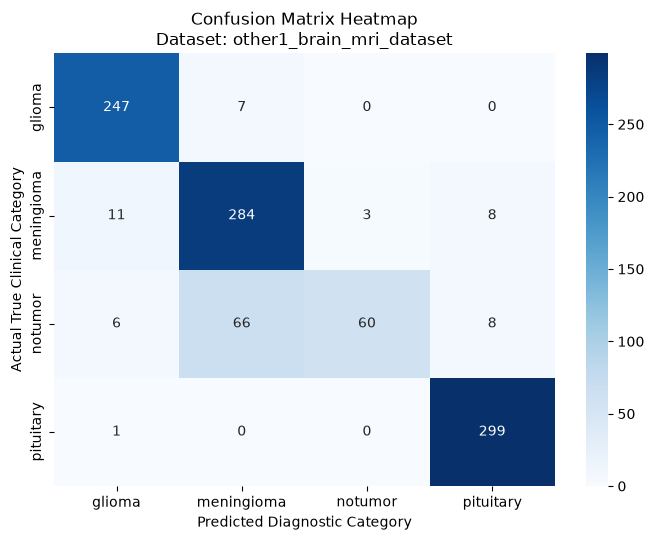


Evaluating Dataset: other2_brain_mri_dataset...

================ FINAL PERFORMANCE REPORT: other2_brain_mri_dataset ================
              precision    recall  f1-score   support

      glioma     0.9922    0.9338    0.9621       136
  meningioma     0.9211    1.0000    0.9589       140
     notumor     1.0000    0.9600    0.9796       100
   pituitary     1.0000    1.0000    1.0000       136

    accuracy                         0.9746       512
   macro avg     0.9783    0.9735    0.9752       512
weighted avg     0.9763    0.9746    0.9747       512




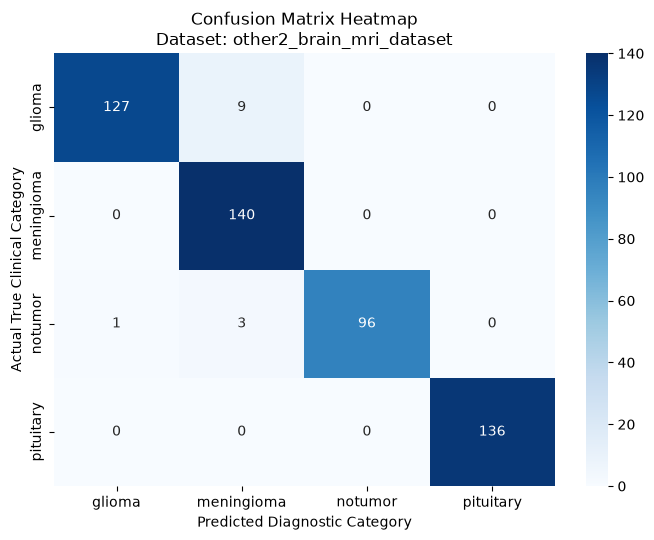

In [11]:
# evaluate Dataset 1
evaluate_dataset(other1_loader, "other1_brain_mri_dataset")

# evaluate Dataset 2
evaluate_dataset(other2_loader, "other2_brain_mri_dataset")